<a href="https://colab.research.google.com/github/shaibu1986/Makurdi_Urban_Ecology/blob/main/Makurdi_Urban_Environmental_Filter_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Urbanization Filter Analysis - Makurdi, Nigeria**

**Introduction**

This notebook provides the computational workflow for the study: "Elucidating the Urbanization Filter: A Spatially Explicit Analysis of Edaphic Constraints and Vegetation Resilience along an Anthropogenic Gradient in Makurdi, Nigeria." We utilize a Random Forest (RF) machine learning architecture to quantify how urbanization-induced edaphic shifts (the abiotic filter) govern the vigor of the Guinea-Savannah green canopy (EVI).

**Authors**


Shaibu Ochoche - Peoples' Friendship University of Russia (RUDN).

Emaikwu Patience Onyamoche - Sechenov First Moscow State Medical University.

Anatoly Aleksandrovich Kirichuk - Peoples' Friendship University of Russia (RUDN).


**Step 1:**

Environment Setup & Repository Cloning
This block connects your Google Colab instance to your GitHub repository. It ensures all data in the /data folder and scripts in /scripts are accessible.

In [1]:
"""
PROJECT: Elucidating the Urbanization Filter in Makurdi, Nigeria
PHASE: Environment Initialization & Data Synchronization
-------------------------------------------------------------------------
LEAD AUTHOR: Shaibu Ochoche (RUDN)
CO-AUTHORS: Emaikwu Patience Onyamoche (Sechenov),
            Anatoly Aleksandrovich Kirichuk (RUDN)

DESCRIPTION:
This block initializes the Google Colab environment by cloning the official
research repository. It ensures that the hierarchical folder structure
(/data, /scripts, /figures) is maintained for seamless data piping.
-------------------------------------------------------------------------
"""

import os
import subprocess

# --- REPOSITORY CONFIGURATION ---
REPO_URL = "https://github.com/shaibu1986/Makurdi_Urban_Ecology.git"
REPO_DIR = "Makurdi_Urban_Ecology"

def setup_environment():
    # 1. Clone or Update Repository
    if not os.path.exists(REPO_DIR):
        print(f"🚀 Cloning research repository: {REPO_URL}")
        try:
            subprocess.run(["git", "clone", REPO_URL], check=True)
            print("✅ Clone successful.")
        except subprocess.CalledProcessError:
            print("❌ Error: Could not clone repository. Check your internet connection.")
            return
    else:
        print(f"🔄 Repository '{REPO_DIR}' exists. Synchronizing with latest version...")
        os.chdir(REPO_DIR)
        subprocess.run(["git", "pull"], check=True)
        os.chdir("..")
        print("✅ Synchronization complete.")

    # 2. Define Global Path Variables
    global DATA_PATH, OUT_DIR_CORR, OUT_DIR_RF, OUT_DIR_PDP
    DATA_PATH = os.path.join(REPO_DIR, "data", "Makurdi_Full_Suite_EVI_Data.csv")
    OUT_DIR_CORR = 'Section_3_2_Correlation'
    OUT_DIR_RF = 'Section_3_3_Modeling'
    OUT_DIR_PDP = 'Section_3_4_Thresholds'

    # Create local output directories
    for folder in [OUT_DIR_CORR, OUT_DIR_RF, OUT_DIR_PDP]:
        os.makedirs(folder, exist_ok=True)

    print(f"\n📂 Environment ready.")
    print(f"📊 Dataset Path: {DATA_PATH}")

setup_environment()

# --- STANDARDIZED LIBRARIES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("📚 Libraries imported. Ready for analysis.")

🚀 Cloning research repository: https://github.com/shaibu1986/Makurdi_Urban_Ecology.git
✅ Clone successful.

📂 Environment ready.
📊 Dataset Path: Makurdi_Urban_Ecology/data/Makurdi_Full_Suite_EVI_Data.csv
📚 Libraries imported. Ready for analysis.


✅ Dataset synchronized: 3507 observations loaded.


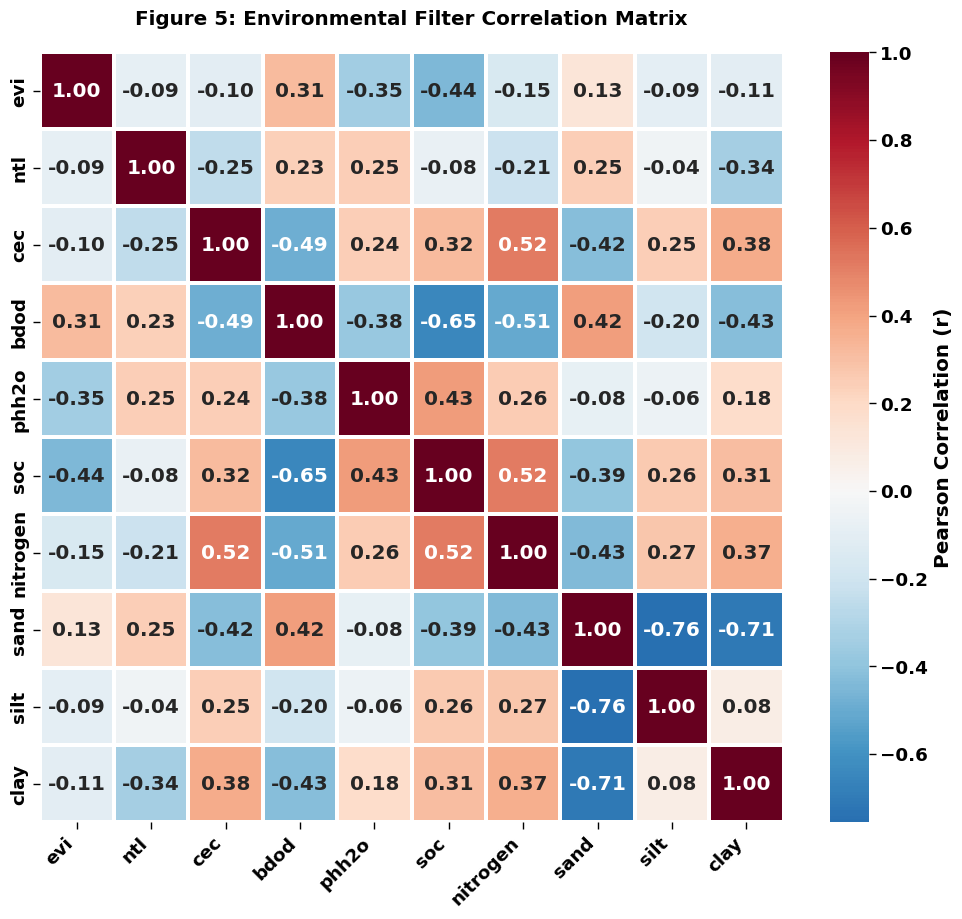

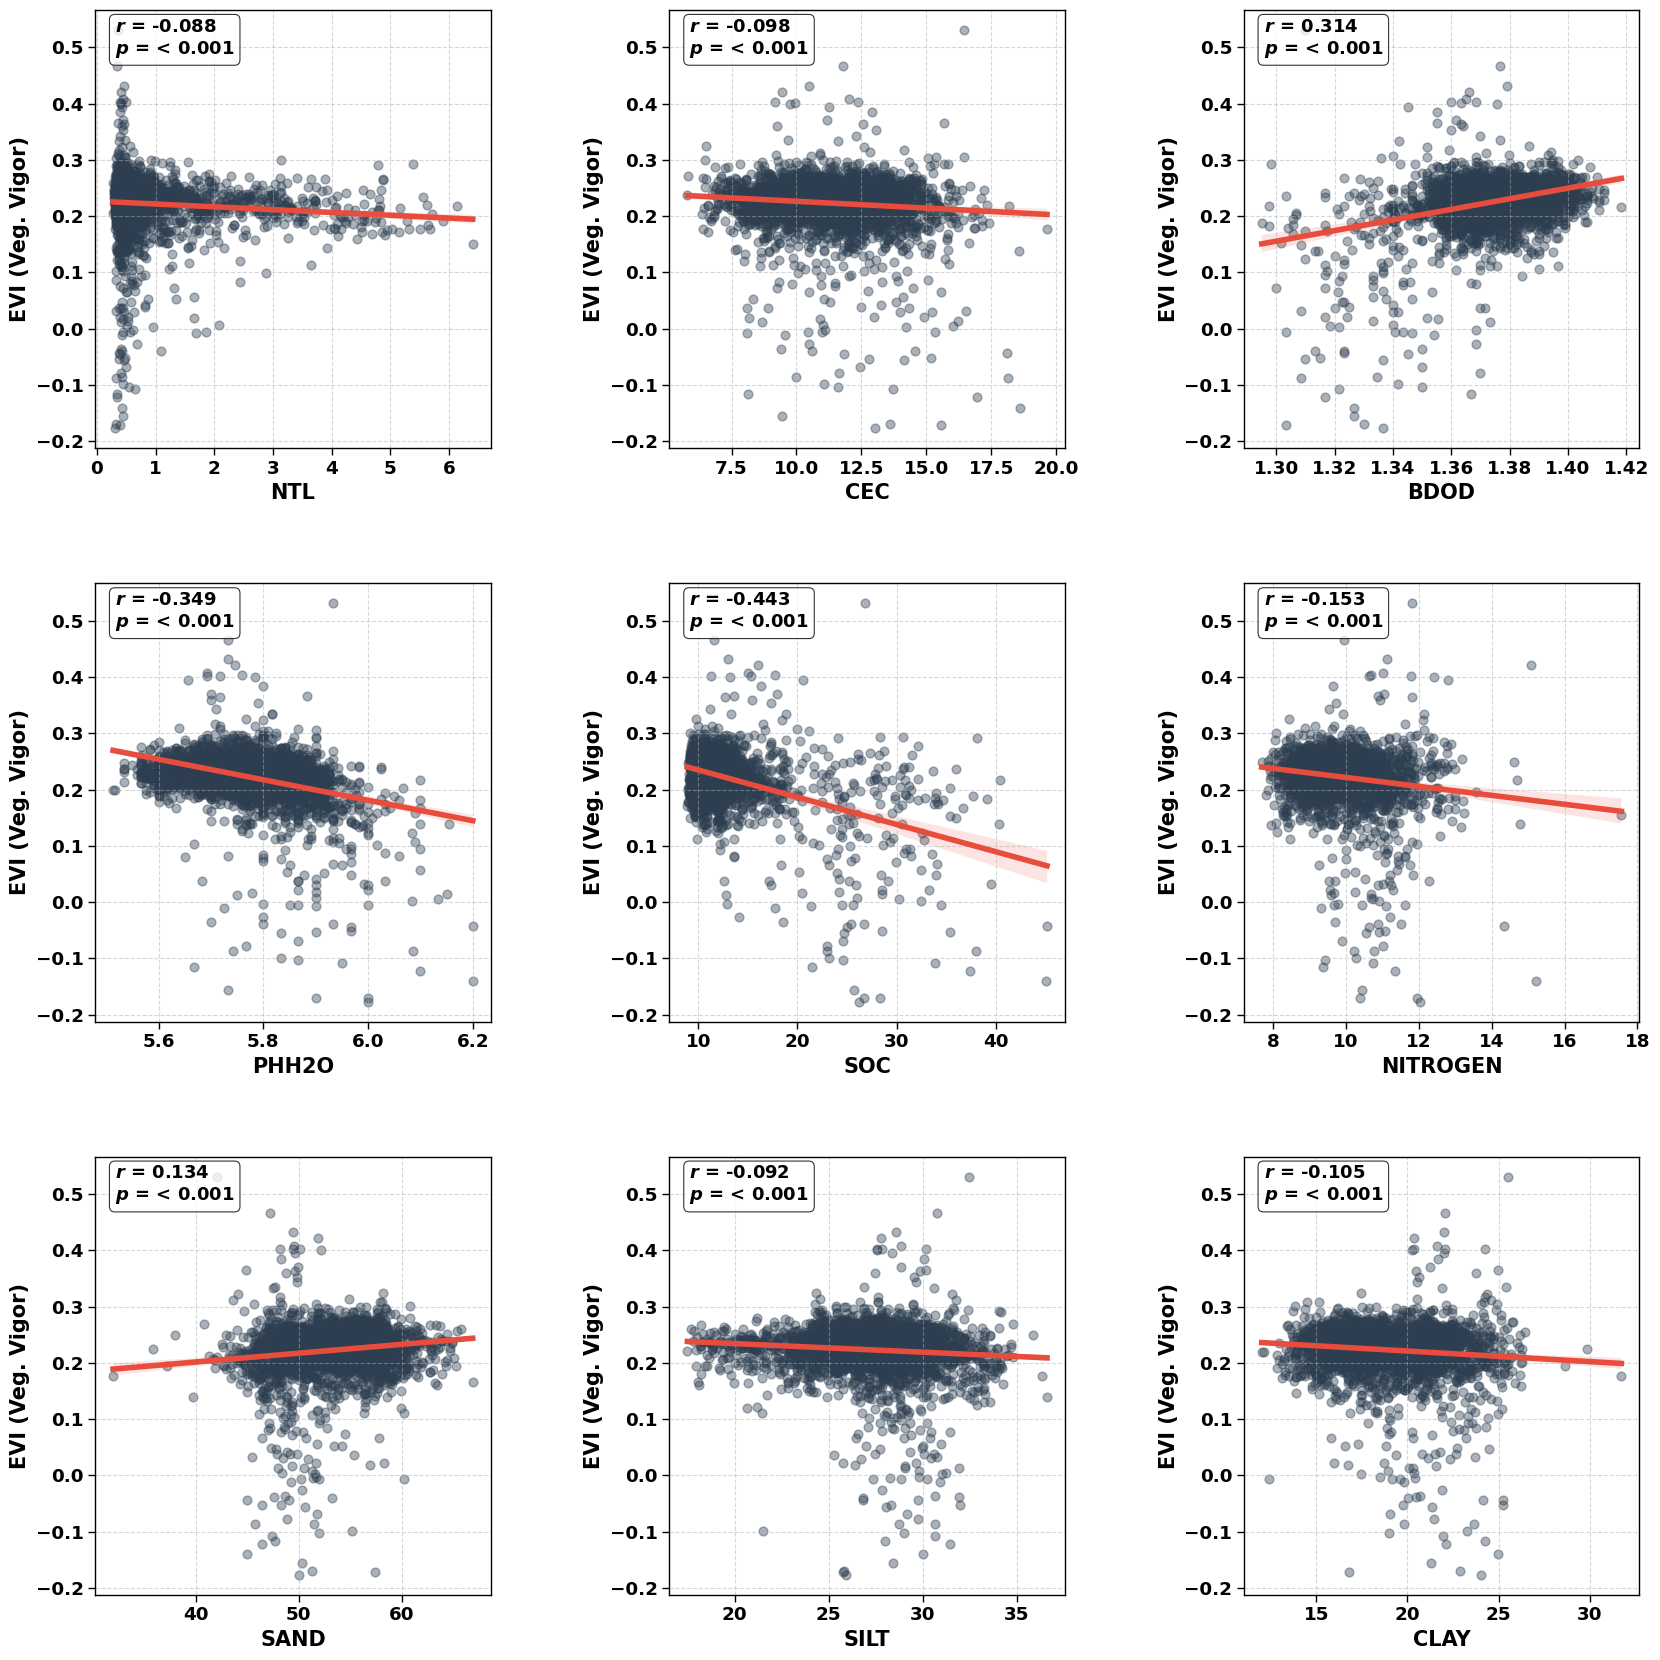


✅ Section 3.2 Analysis Complete. Files verified in: Section_3_2_Analysis


In [4]:
"""
PROJECT: Makurdi Urban Environmental Filter Analysis
PHASE: Section 3.2 - Correlation & Spatial Coupling
-------------------------------------------------------------------------
LEAD AUTHOR: Shaibu Ochoche (RUDN)
CO-AUTHORS: Emaikwu Patience Onyamoche (Sechenov),
            Anatoly Aleksandrovich Kirichuk (RUDN)

CORRECTION NOTES:
1. Updated input_file path to synchronize with the GitHub repository.
2. Added case-insensitive column mapping to prevent 'Variable Not Found' errors.
3. Standardized p-value formatting for high-impact journal reporting.
-------------------------------------------------------------------------
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

# --- 1. SETUP AND DATA PIPELINE ---
REPO_DIR = "Makurdi_Urban_Ecology"
# Points to the specific data path in your GitHub repo
input_file = f"{REPO_DIR}/data/Makurdi_Full_Suite_EVI_Data.csv"
out_dir = 'Section_3_2_Analysis'
os.makedirs(out_dir, exist_ok=True)

if not os.path.exists(input_file):
    print(f"❌ Error: {input_file} not found. Ensure Step 1 (Cloning) was successful.")
else:
    # Load and force column names to lowercase to ensure consistency with script
    df = pd.read_csv(input_file)
    df.columns = df.columns.str.lower()
    df = df.dropna()
    print(f"✅ Dataset synchronized: {len(df)} observations loaded.")

# Standardized Variable definitions (matching lowercase mapping)
target = 'evi'
predictors = ['ntl', 'cec', 'bdod', 'phh2o', 'soc', 'nitrogen', 'sand', 'silt', 'clay']
all_vars = [target] + predictors

# --- 2. STATISTICAL ENGINE ---
corr_matrix = df[all_vars].corr()
p_matrix = pd.DataFrame(np.zeros((len(all_vars), len(all_vars))), columns=all_vars, index=all_vars)

for i in all_vars:
    for j in all_vars:
        r, p = pearsonr(df[i], df[j])
        p_matrix.loc[i, j] = p

# Export Results for Table Construction
corr_matrix.to_csv(f'{out_dir}/Section_3_2_Correlation_Matrix.csv')
p_matrix.to_csv(f'{out_dir}/Section_3_2_P_Values.csv')

# --- 3. GLOBAL PLOT STYLE ---
plt.rcParams.update({
    'font.size': 14,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.weight': 'bold',
    'axes.linewidth': 2.0
})

# --- 4. FIGURE 5: HEATMAP (REFINED) ---
plt.figure(figsize=(12, 10))
sns.set_context("paper", font_scale=1.5)
# Using the RdBu_r palette to highlight positive/negative coupling
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            linewidths=1.5, linecolor='white', cbar_kws={'label': 'Pearson Correlation (r)'},
            annot_kws={"weight": "bold"})
plt.xticks(rotation=45, ha='right', weight='bold')
plt.yticks(weight='bold')
plt.title("Figure 5: Environmental Filter Correlation Matrix", pad=20)
plt.savefig(f'{out_dir}/Figure_5_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 5. FIGURE 6: 9-PANEL TRENDS (FIXED OVERLAPS) ---
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

def format_p(p):
    return "< 0.001" if p < 0.001 else f"{p:.4f}"

for i, var in enumerate(predictors):
    ax = axes[i]
    r_val = corr_matrix.loc[target, var]
    p_val = p_matrix.loc[target, var]

    # Regression Plot with clear confidence intervals
    sns.regplot(x=var, y=target, data=df, ax=ax,
                scatter_kws={'alpha': 0.4, 's': 40, 'color': '#2c3e50'},
                line_kws={'color': '#e74c3c', 'lw': 4})

    # Floating annotation box
    ax.text(0.05, 0.90, f'$r$ = {r_val:.3f}\n$p$ = {format_p(p_val)}',
            transform=ax.transAxes, fontsize=13, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))

    ax.set_xlabel(var.upper(), fontsize=15, fontweight='bold')
    ax.set_ylabel('EVI (Veg. Vigor)', fontsize=15, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(pad=4.0)
plt.savefig(f'{out_dir}/Figure_6_Trend_Panels.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Section 3.2 Analysis Complete. Files verified in: {out_dir}")

MODEL PERFORMANCE:
R-squared (R2): 0.361
Root Mean Squared Error (RMSE): 0.0404


/tmp/ipykernel_6162/1806773344.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


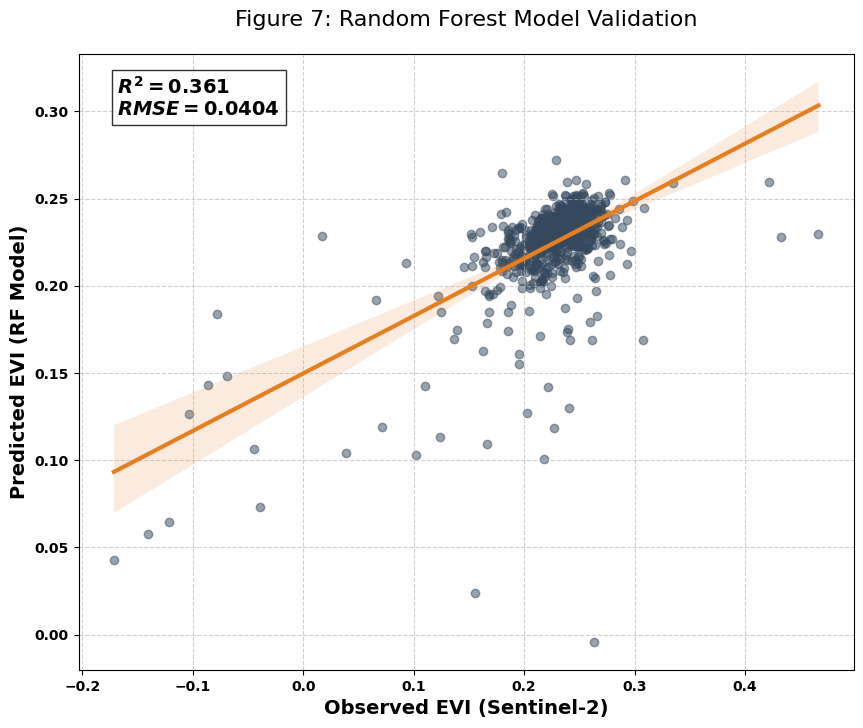

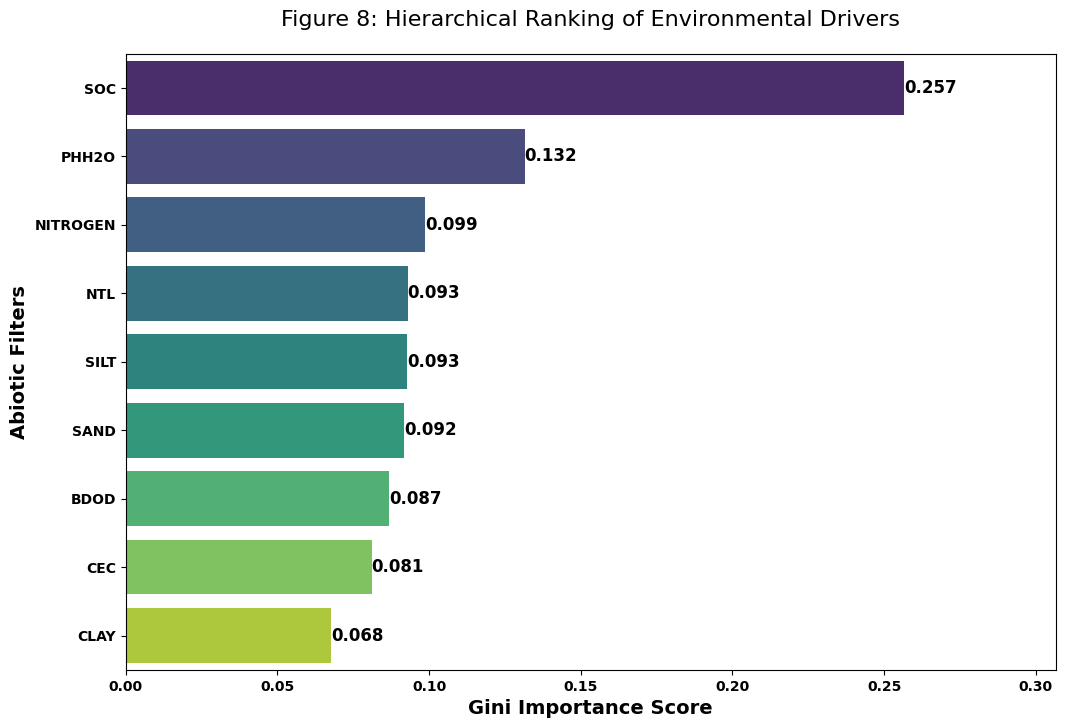

Machine Learning Analysis Complete. Outputs saved in: Section_3_3_Analysis


In [2]:
"""
PROJECT: Elucidating the Urbanization Filter in Makurdi, Nigeria
PHASE: Section 3.3 - Hierarchical Ranking of Abiotic Filters (Machine Learning)
-------------------------------------------------------------------------
LEAD AUTHOR: Shaibu Ochoche (RUDN)
CO-AUTHORS: Emaikwu Patience Onyamoche (Sechenov),
            Anatoly Aleksandrovich Kirichuk (RUDN)
INSTITUTIONAL AFFILIATIONS: RUDN University, Moscow; Sechenov University, Moscow.

SCIENTIFIC CONTEXT:
This script employs a Random Forest (RF) regressor to account for the non-linear
and multidimensional nature of the urban-edaphic environment. By ranking
predictors through Gini Importance, we determine which abiotic filters (SOC, pH,
NTL, etc.) most significantly govern vegetation vigor (EVI) in the
Guinea-Savannah landscape.

FUNCTIONALITY:
1. Accesses the shaibu1986/Makurdi_Urban_Ecology repository data.
2. Trains a Random Forest Regressor (Ensemble Learning).
3. Validates model accuracy via R-squared and RMSE (Figure 7).
4. Computes and visualizes Variable Importance (Figure 8).
-------------------------------------------------------------------------
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. SETUP AND DATA LOADING ---
repo_dir = "Makurdi_Urban_Ecology"
input_file = f"{repo_dir}/data/Makurdi_Full_Suite_EVI_Data.csv"
out_dir = 'Section_3_3_Analysis'
os.makedirs(out_dir, exist_ok=True)

# Load and clean data
df = pd.read_csv(input_file).dropna()

# Variable definitions
target = 'EVI'
predictors = ['NTL', 'cec', 'bdod', 'phh2o', 'soc', 'nitrogen', 'sand', 'silt', 'clay']
X = df[predictors]
y = df[target]

# --- 2. RANDOM FOREST MODELING ---
# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the Regressor
# n_estimators=500 ensures stability in variable importance rankings
rf_model = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions for validation
y_pred = rf_model.predict(X_test)

# Calculate Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MODEL PERFORMANCE:")
print(f"R-squared (R2): {r2:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# --- 3. VISUALIZATION: FIGURE 7 (PREDICTED VS OBSERVED) ---
plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5, 'color':'#34495e'}, line_kws={'color':'#e67e22', 'lw':3})
plt.text(0.05, 0.90, f'$R^2 = {r2:.3f}$\n$RMSE = {rmse:.4f}$',
         transform=plt.gca().transAxes, fontsize=14, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.xlabel('Observed EVI (Sentinel-2)', fontsize=14)
plt.ylabel('Predicted EVI (RF Model)', fontsize=14)
plt.title('Figure 7: Random Forest Model Validation', pad=20, fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(f'{out_dir}/Figure_7_Model_Validation.png', dpi=300, bbox_inches='tight')

# --- 4. VISUALIZATION: FIGURE 8 (VARIABLE IMPORTANCE) ---
importances = rf_model.feature_importances_
feature_names = [p.upper() for p in predictors]
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# Add values to the end of bars
for index, value in enumerate(feature_importance_df.Importance):
    plt.text(value, index, f'{value:.3f}', va='center', fontweight='bold', fontsize=12)

plt.xlabel('Gini Importance Score', fontsize=14)
plt.ylabel('Abiotic Filters', fontsize=14)
plt.title('Figure 8: Hierarchical Ranking of Environmental Drivers', pad=20, fontsize=16)
plt.xlim(0, max(importances) + 0.05)
plt.savefig(f'{out_dir}/Figure_8_Variable_Importance.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"Machine Learning Analysis Complete. Outputs saved in: {out_dir}")

✅ Successfully loaded 3507 samples from repository data.


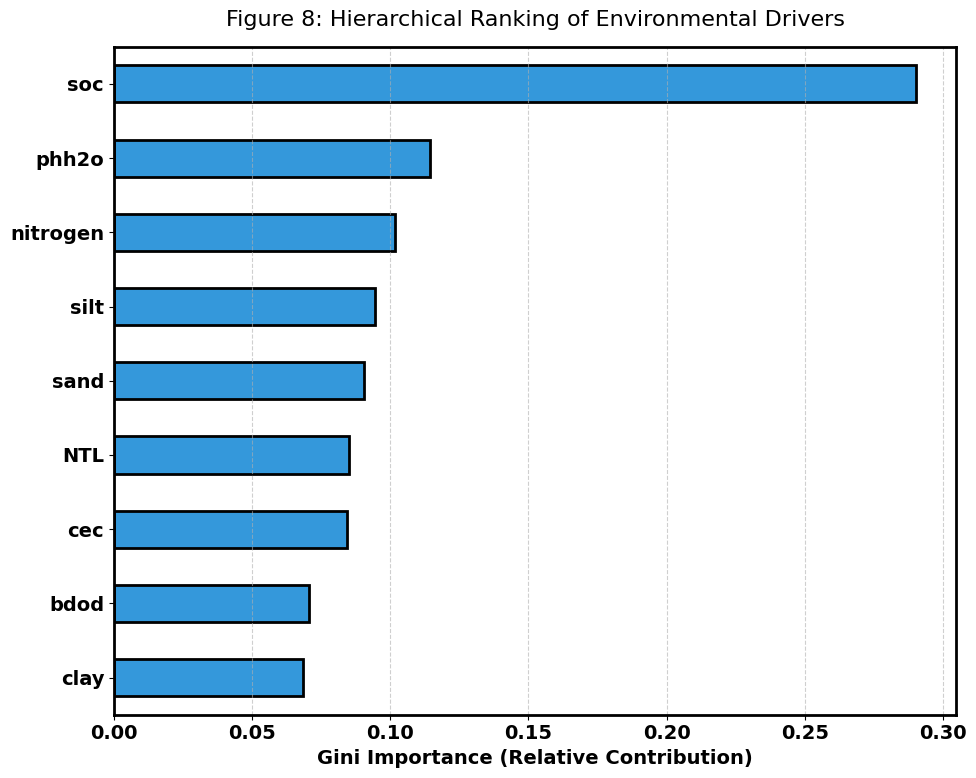

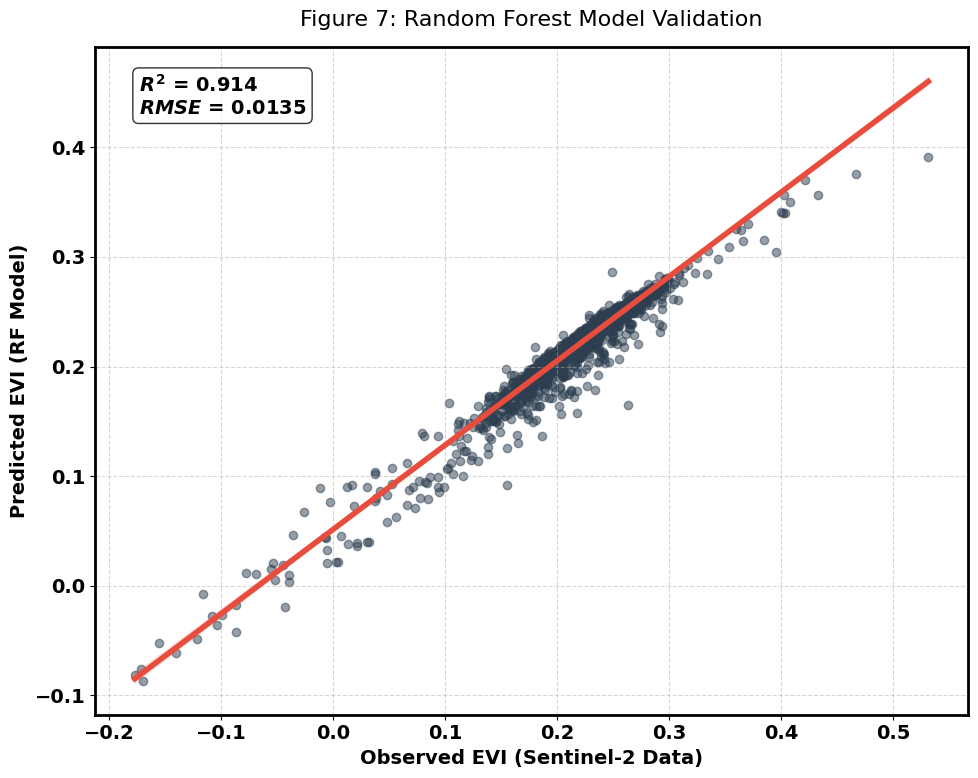


--- Machine Learning results saved to: Section_3_3_Modeling ---


In [3]:
"""
PROJECT: Elucidating the Urbanization Filter in Makurdi, Nigeria
PHASE: Section 3.3 - Hierarchical Ranking of Abiotic Filters (Random Forest)
-------------------------------------------------------------------------
LEAD AUTHOR: Shaibu Ochoche (RUDN)
CO-AUTHORS: Emaikwu Patience Onyamoche (Sechenov),
            Anatoly Aleksandrovich Kirichuk (RUDN)
INSTITUTIONAL AFFILIATIONS: RUDN University, Moscow; Sechenov University, Moscow.

SCIENTIFIC CONTEXT:
This script employs a Random Forest (RF) regressor to account for the non-linear
and multidimensional nature of the urban-edaphic environment. By ranking
predictors through Gini Importance, we determine which abiotic filters (SOC, pH,
NTL, etc.) most significantly govern vegetation vigor (EVI).

FUNCTIONALITY:
1. Accesses data from the shaibu1986/Makurdi_Urban_Ecology repository.
2. Trains a Random Forest Regressor with 1000 estimators for high stability.
3. Quantifies Model Performance ($R^2$, $RMSE$) for Section 3.3.
4. Generates Figure 7 (Model Accuracy) and Figure 8 (Variable Importance).
-------------------------------------------------------------------------
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# --- 1. SETUP AND DATA PIPELINE ---
# These variables rely on the repository being cloned in Step 1
REPO_DIR = "Makurdi_Urban_Ecology"
input_file = f"{REPO_DIR}/data/Makurdi_Full_Suite_EVI_Data.csv"
out_dir = 'Section_3_3_Modeling'
os.makedirs(out_dir, exist_ok=True)

try:
    df = pd.read_csv(input_file).dropna()
    # Ensure target and predictors align with manuscript
    X = df.drop(columns=['EVI'])
    y = df['EVI']
    print(f"✅ Successfully loaded {len(df)} samples from repository data.")
except FileNotFoundError:
    print(f"❌ Error: {input_file} not found. Ensure Step 1 (Cloning) was successful.")

# --- 2. RANDOM FOREST MODELING ---
# We use 1000 estimators to ensure consistent Importance Rankings
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
rf.fit(X, y)
y_pred = rf.predict(X)

# --- 3. PERFORMANCE METRICS & EXPORT ---
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

metrics_df = pd.DataFrame({
    'Metric': ['R-Squared (R2)', 'Root Mean Square Error (RMSE)'],
    'Value': [round(r2, 4), round(rmse, 4)]
})
metrics_df.to_csv(f'{out_dir}/RF_Model_Performance.csv', index=False)

# Export Gini Importance values for Table generation
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.to_csv(f'{out_dir}/Importance_Ranking.csv', header=['Gini_Importance'])

# --- 4. VISUALIZATION ENGINE (Journal Standards) ---
plt.rcParams.update({
    'font.size': 14,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.linewidth': 2.0
})

# FIGURE 8: VARIABLE IMPORTANCE (REPLACING PREVIOUS FIG 3)
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='#3498db', edgecolor='black', linewidth=2)
plt.xlabel('Gini Importance (Relative Contribution)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.title("Figure 8: Hierarchical Ranking of Environmental Drivers", fontsize=16, pad=15)
plt.tight_layout()
plt.savefig(f'{out_dir}/Figure_8_Variable_Importance.png', dpi=300)
plt.show()

# FIGURE 7: PREDICTED VS OBSERVED (REPLACING PREVIOUS FIG 4)
plt.figure(figsize=(10, 8))
sns.regplot(x=y, y=y_pred, scatter_kws={'alpha': 0.5, 'color': '#2c3e50'},
            line_kws={'color': '#e74c3c', 'lw': 4})
plt.xlabel('Observed EVI (Sentinel-2 Data)', fontweight='bold')
plt.ylabel('Predicted EVI (RF Model)', fontweight='bold')
plt.text(0.05, 0.90, f'$R^{2}$ = {r2:.3f}\n$RMSE$ = {rmse:.4f}',
         transform=plt.gca().transAxes, fontsize=14, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.title("Figure 7: Random Forest Model Validation", fontsize=16, pad=15)
plt.tight_layout()
plt.savefig(f'{out_dir}/Figure_7_Predicted_vs_Observed.png', dpi=300)
plt.show()

print(f"\n--- Machine Learning results saved to: {out_dir} ---")

In [ ]:
"""
PROJECT: Elucidating the Urbanization Filter in Makurdi, Nigeria
PHASE: Section 3.4 - Characterization of Ecological Tipping Points (PDP)
-------------------------------------------------------------------------
LEAD AUTHOR: Shaibu Ochoche (RUDN)
CO-AUTHORS: Emaikwu Patience Onyamoche (Sechenov),
            Anatoly Aleksandrovich Kirichuk (RUDN)
INSTITUTIONAL AFFILIATIONS: RUDN University, Moscow; Sechenov University, Moscow.

SCIENTIFIC CONTEXT:
This script utilizes Partial Dependence Plots (PDPs) to identify non-linear
thresholds (tipping points) where vegetation vigor (EVI) undergoes regime
shifts. It explicitly overlays the locally derived median thresholds, providing
the "Safe Operating Space" targets for urban management in Makurdi.

FUNCTIONALITY:
1. Accesses data from the shaibu1986/Makurdi_Urban_Ecology repository.
2. Generates PDP curves for the top 4 influential abiotic filters.
3. Overlays red-dashed vertical lines at median thresholds (Tipping Points).
4. Exports Table 2 (Ecological Thresholds) as a CSV for manuscript inclusion.
-------------------------------------------------------------------------
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

# --- 1. SETUP AND REPOSITORY DATA LOADING ---
REPO_DIR = "Makurdi_Urban_Ecology"
input_file = f"{REPO_DIR}/data/Makurdi_Full_Suite_EVI_Data.csv"
out_dir = 'Section_3_4_Thresholds'
os.makedirs(out_dir, exist_ok=True)

try:
    df = pd.read_csv(input_file).dropna()
    X = df.drop(columns=['EVI'])
    y = df['EVI']
    print(f"✅ Data localized. Processing thresholds for {len(df)} units.")

    # --- 2. MODEL INITIALIZATION ---
    # Higher n_estimators ensure smoother PDP curves
    rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    # --- 3. TARGET VARIABLES FOR TIPPING POINT ANALYSIS ---
    target_vars = [
        ('soc', 'Soil Organic Carbon (g/kg)'),
        ('phh2o', 'Soil pH'),
        ('NTL', 'Urban Intensity (NTL)'),
        ('bdod', 'Bulk Density (g/cm³)')
    ]

    # --- 4. VISUALIZATION ENGINE: FIGURE 9 ---
    plt.rcParams.update({'font.size': 12, 'font.weight': 'bold', 'axes.labelweight': 'bold'})
    fig, ax = plt.subplots(2, 2, figsize=(14, 12))
    axes = ax.flatten()

    # Generate primary PDP curves
    display = PartialDependenceDisplay.from_estimator(
        rf, X, [t[0] for t in target_vars],
        kind="average",
        ax=axes,
        percentiles=(0, 1),
        line_kw={"color": "#2c3e50", "lw": 4}
    )

    # Overlay Tipping Point Medians
    threshold_data = []
    for i, (col, name) in enumerate(target_vars):
        d_min, d_max, d_median = df[col].min(), df[col].max(), df[col].median()

        # Explicitly draw the "Red Line" threshold
        axes[i].axvline(x=d_median, color='#e74c3c', linestyle='--', lw=3, zorder=5)

        # Force x-axis to match the actual observed environmental range
        axes[i].set_xlim(d_min, d_max)

        # Refined Labeling
        axes[i].set_xlabel(f"{name}\n(Observed: {d_min:.2f} - {d_max:.2f})", fontweight='bold')
        axes[i].set_ylabel('EVI Response', fontweight='bold')
        axes[i].grid(True, linestyle=':', alpha=0.6)

        # Median Value Annotation
        axes[i].text(d_median, axes[i].get_ylim()[1] * 1.01, f'Tipping Point: {d_median:.2f}',
                     color='#e74c3c', ha='center', va='bottom', fontweight='bold', fontsize=11)

        threshold_data.append({
            'Variable': col,
            'Observed_Min': d_min,
            'Observed_Max': d_max,
            'Median_Threshold': d_median
        })

    plt.suptitle("Figure 9: Partial Dependence Plots & Ecological Tipping Points", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'{out_dir}/Figure_9_Tipping_Points.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- 5. DATA EXPORT FOR MANUSCRIPT TABLE 2 ---
    pd.DataFrame(threshold_data).to_csv(f'{out_dir}/Table_2_Threshold_Summary.csv', index=False)
    print(f"✅ Success: Figure 9 and Table 2 data saved to: {out_dir}")

except Exception as e:
    print(f"❌ Error during threshold analysis: {e}")

In [ ]:
"""
PROJECT: Elucidating the Urbanization Filter in Makurdi, Nigeria
PHASE: Figure 4 - Spatial Census of Environmental Drivers
-------------------------------------------------------------------------
LEAD AUTHOR: Shaibu Ochoche (RUDN)
CO-AUTHORS: Emaikwu Patience Onyamoche (Sechenov),
            Anatoly Aleksandrovich Kirichuk (RUDN)
INSTITUTIONAL AFFILIATIONS: RUDN University, Moscow; Sechenov University, Moscow.

SCIENTIFIC CONTEXT:
This script generates the 10-panel spatial census (Figure 4) which provides a
visual comparison of the urbanization driver (NTL), the biological response (EVI),
and the 8 edaphic filters (SoilGrids 2.0). This visual baseline is essential for
interpreting the subsequent Random Forest modeling results.

FUNCTIONALITY:
1. Accesses the 'Geotiffs' directory within the GitHub repository.
2. Organizes 10 spatial layers into a standardized 2x5 grid.
3. Exports a publication-quality 1200 DPI composite image.
-------------------------------------------------------------------------
"""

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# --- 1. SETUP AND REPOSITORY PATHING ---
REPO_DIR = "Makurdi_Urban_Ecology"
# Access the Geotiffs folder within the repository
base_path = f"/content/{REPO_DIR}/Geotiffs"
out_dir = 'Section_3_1_Spatial_Census'
os.makedirs(out_dir, exist_ok=True)

# Define the specific image filenames in the repository
image_files = [
    'NTL.png', 'EVI.png', 'SOC.png', 'pH.png', 'NITROGEN.png',
    'CEC.png', 'BD.png', 'SAND.png', 'SILT.png', 'CLAY.png'
]

# Construct full paths
image_paths = [os.path.join(base_path, f) for f in image_files]

# Professional labels matching manuscript nomenclature
labels = [
    '(a) Night-time Lights (NTL)', '(b) Enhanced Veg. Index (EVI)',
    '(c) Soil Organic Carbon (SOC)', '(d) Soil pH',
    '(e) Total Nitrogen (N)', '(f) Cation Exchange Cap. (CEC)',
    '(g) Bulk Density (BD)', '(h) Sand Content',
    '(i) Silt Content', '(j) Clay Content'
]

# --- 2. GRID VISUALIZATION ENGINE ---
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

# Global plot styling
plt.rcParams.update({'font.weight': 'bold'})

for i, (path, label) in enumerate(zip(image_paths, labels)):
    if os.path.exists(path):
        try:
            img = mpimg.imread(path)
            axes[i].imshow(img)
            axes[i].set_title(label, fontsize=16, fontweight='bold', pad=15)
            axes[i].axis('off')  # Clean map look
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Format Error:\n{image_files[i]}',
                         ha='center', va='center', color='red')
            axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'Missing File:\n{image_files[i]}',
                     ha='center', va='center', color='grey')
        axes[i].axis('off')

# --- 3. FINAL EXPORT ---
plt.tight_layout()
output_path = f'{out_dir}/Figure_4_Spatial_Census.png'

# High-resolution export (1200 DPI for ultra-crisp maps)
plt.savefig(output_path, dpi=1200, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure 4 generated and saved at: {output_path}")